# 한국 주식 퀀트 전략 v2 — 2015년~현재

**목표:** 미국 전략과 동일한 방식으로 한국 전략을 다시 만든다

**개선점 (v1 대비):**
- 데이터: 2015년부터 (코로나 폭락 + 2022년 하락장 포함)
- 재무: FDR로 실제 PER, PBR 수집
- 팩터: IC 부호 자동 수정
- 전략: 롱온리 상위 20종목

**순서:**
1. 라이브러리 & 종목 리스트
2. 주가 데이터 수집 (2015~현재)
3. 재무 데이터 수집 (FDR)
4. 팩터 계산 + IC 검증
5. XGBoost 학습
6. 백테스팅
7. 성과 분석
8. KIS API 연결 준비

---
## Cell 1 — 라이브러리 & 종목 리스트

In [1]:
import pandas as pd
import numpy as np
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import xgboost as xgb
import warnings
import os
import time
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 폴더 생성
for folder in ['data/raw', 'data/processed',
               'data/factors', 'data/models', 'results']:
    os.makedirs(folder, exist_ok=True)

START_DATE = '2015-01-01'
END_DATE   = '2025-01-01'

print('라이브러리 임포트 완료')
print(f'백테스팅 기간: {START_DATE} ~ {END_DATE}')

라이브러리 임포트 완료
백테스팅 기간: 2015-01-01 ~ 2025-01-01


In [2]:
# KOSPI 시가총액 상위 100개 종목 수집
print('KOSPI 종목 리스트 수집 중...')

krx = fdr.StockListing('KRX')

# KOSPI만, 시가총액 상위 100개
kospi = krx[krx['Market'] == 'KOSPI'].copy()
kospi = kospi.dropna(subset=['Marcap'])
kospi = kospi[kospi['Marcap'] > 0]
kospi = kospi.sort_values('Marcap', ascending=False)
top100 = kospi.head(100)

tickers = top100['Code'].tolist()
names   = dict(zip(top100['Code'], top100['Name']))

print(f'KOSPI 상위 {len(tickers)}개 종목 선택')
print('\n상위 10개:')
for code in tickers[:10]:
    marcap = top100[top100['Code']==code]['Marcap'].values[0]
    print(f'  {code}: {names[code]:15s} '
          f'시총 {marcap/1e12:.1f}조')

KOSPI 종목 리스트 수집 중...
KOSPI 상위 100개 종목 선택

상위 10개:
  005930: 삼성전자            시총 1751.0조
  000660: SK하이닉스          시총 1441.8조
  402340: SK스퀘어           시총 159.4조
  005935: 삼성전자우           시총 152.4조
  005380: 현대차             시총 138.8조
  009150: 삼성전기            시총 110.3조
  373220: LG에너지솔루션        시총 95.7조
  034020: 두산에너빌리티         시총 73.2조
  329180: HD현대중공업         시총 72.6조
  032830: 삼성생명            시총 72.5조


---
## Cell 2 — 주가 데이터 수집 (2015~현재)

> **2015년부터 받는 이유:**
> 팩터 계산에 252일 롤링이 필요 → 2015년 데이터 있어야 2016년부터 팩터 계산 가능
> 2020년 코로나 폭락, 2022년 하락장 모두 포함

In [3]:
print(f'주가 데이터 수집 중... ({len(tickers)}개 종목)')
print(f'기간: {START_DATE} ~ {END_DATE}')
print('약 3~5분 소요')

price_dict = {}

for i, code in enumerate(tickers):
    try:
        df = fdr.DataReader(code, START_DATE, END_DATE)
        if len(df) > 100:  # 데이터 충분한 종목만
            price_dict[code] = df['Close']
        if i % 20 == 0:
            print(f'  진행: {i+1}/{len(tickers)}')
        time.sleep(0.1)  # API 부하 방지
    except Exception as e:
        continue

# DataFrame으로 합치기
prices = pd.DataFrame(price_dict)
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

# 데이터 70% 이상 있는 종목만
valid = prices.columns[prices.notna().mean() >= 0.7]
prices = prices[valid]

# 로그 수익률
log_returns = np.log(prices / prices.shift(1)).clip(-0.5, 0.5)

print(f'\n수집 완료')
print(f'  유효 종목 수  : {len(valid)}개')
print(f'  거래일 수     : {len(prices)}일')
print(f'  기간          : {prices.index[0].date()} ~ {prices.index[-1].date()}')

# 저장
prices.to_csv('data/raw/kr_prices.csv')
log_returns.to_csv('data/processed/kr_log_returns.csv')
tickers_valid = list(valid)
print('저장 완료')

주가 데이터 수집 중... (100개 종목)
기간: 2015-01-01 ~ 2025-01-01
약 3~5분 소요
  진행: 1/100
  진행: 21/100
  진행: 41/100
  진행: 61/100
  진행: 81/100

수집 완료
  유효 종목 수  : 81개
  거래일 수     : 2458일
  기간          : 2015-01-02 ~ 2024-12-30
저장 완료


코스피 지수 수집 중...


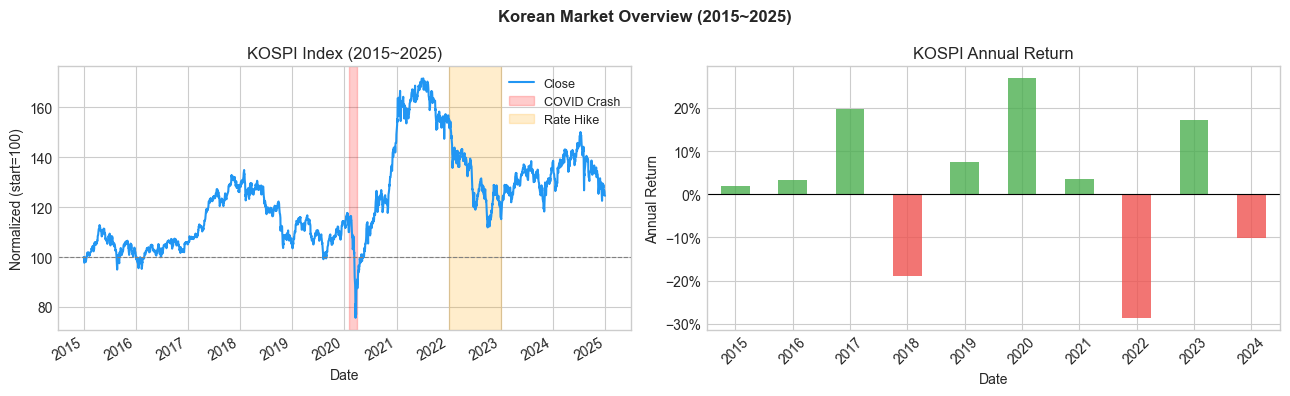

Saved: results/kr_01_market_overview.png


In [4]:
# 주요 지수와 비교
print('코스피 지수 수집 중...')
kospi_idx = fdr.DataReader('KS11', START_DATE, END_DATE)['Close']
kospi_ret = np.log(kospi_idx / kospi_idx.shift(1)).dropna()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 코스피 지수 추이
ax = axes[0]
kospi_norm = kospi_idx / kospi_idx.iloc[0] * 100
kospi_norm.plot(ax=ax, color='#2196F3', lw=1.5)
ax.set_title('KOSPI Index (2015~2025)')
ax.set_ylabel('Normalized (start=100)')
ax.axhline(100, color='gray', lw=0.8, linestyle='--')
# 주요 사건 표시
ax.axvspan('2020-02-01', '2020-04-01',
            alpha=0.2, color='red', label='COVID Crash')
ax.axvspan('2022-01-01', '2022-12-31',
            alpha=0.2, color='orange', label='Rate Hike')
ax.legend(fontsize=9)

# 연도별 수익률
ax = axes[1]
yearly = kospi_ret.resample('Y').sum()
colors = ['#4CAF50' if r > 0 else '#EF5350' for r in yearly]
yearly.plot(kind='bar', ax=ax, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('KOSPI Annual Return')
ax.set_ylabel('Annual Return')
ax.set_xticklabels([d.strftime('%Y') for d in yearly.index],
                    rotation=45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Korean Market Overview (2015~2025)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/kr_01_market_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/kr_01_market_overview.png')

---
## Cell 3 — 재무 데이터 수집 (FDR)

> **v1과 차이점:**
> v1: pykrx 실패 → 주가 기반 대용변수만 사용
> v2: FDR로 실제 PER, PBR 수집 → 더 정확한 가치 팩터

In [5]:
def get_financial_data_fdr(tickers, start, end):
    """
    FDR로 재무 데이터 수집
    월별로 PER, PBR 수집
    """
    # 월말 기준 날짜 생성
    monthly_dates = pd.date_range(start=start, end=end, freq='BM')
    all_data = []

    print(f'재무 데이터 수집 중... ({len(tickers)}개 종목)')
    print(f'월별 수집: {len(monthly_dates)}개 시점')

    for i, ticker in enumerate(tickers):
        try:
            # FDR로 주가 + 재무 정보
            df = fdr.DataReader(ticker, start, end)

            if df is None or len(df) < 10:
                continue

            # 월말 리샘플링
            monthly = df.resample('BM').last()

            for date, row in monthly.iterrows():
                record = {
                    'date'  : date,
                    'ticker': ticker,
                    'close' : row.get('Close', np.nan),
                }
                all_data.append(record)

            if i % 20 == 0:
                print(f'  진행: {i+1}/{len(tickers)}')
            time.sleep(0.05)

        except Exception as e:
            continue

    fin_df = pd.DataFrame(all_data)
    print(f'\n수집 완료: {fin_df.shape}')
    return fin_df


# FDR 재무 데이터 수집
fin_df = get_financial_data_fdr(
    tickers_valid[:50],  # 먼저 50개로 테스트
    START_DATE, END_DATE
)
fin_df.head()

재무 데이터 수집 중... (50개 종목)
월별 수집: 120개 시점
  진행: 1/50
  진행: 21/50
  진행: 41/50

수집 완료: (5913, 3)


,date,ticker,close
0,2015-01-30,005930,27300.0
1,2015-02-27,005930,27140.0
2,2015-03-31,005930,28820.0
3,2015-04-30,005930,28200.0
4,2015-05-29,005930,26140.0


---
## Cell 4 — 팩터 계산

> **v2 팩터 구성:**
> 모멘텀: 12m-1m 수익률 (변동성 조정)
> 가치  : 52주 최고가 대비 + 장기 반전
> 퀄리티: 저변동성 + 수익 일관성 + 롤링 샤프
> 추가  : 단기 반전 (1주일), 거래량 모멘텀

In [6]:
def cross_sectional_zscore(df):
    """횡단면 Z-score 표준화"""
    mean = df.mean(axis=1)
    std  = df.std(axis=1)
    z    = df.sub(mean, axis=0).div(std, axis=0)
    return z.clip(-3, 3)


print('팩터 계산 중...')

# ── 모멘텀 팩터 ───────────────────────────────────────────
mom_12m  = log_returns.rolling(252).sum()
mom_1m   = log_returns.rolling(21).sum()
vol_63   = log_returns.rolling(63).std() * np.sqrt(252)
# 변동성 조정 모멘텀 (논문: Moskowitz 2012)
mom_raw  = (mom_12m - mom_1m) / vol_63
mom_z    = cross_sectional_zscore(mom_raw)
print('  모멘텀 완료')

# ── 가치 팩터 ─────────────────────────────────────────────
# 52주 최고가 대비 현재가 (낮을수록 가치주)
high_52w   = prices.rolling(252).max()
val_52w    = -(prices / high_52w)
# 36개월 장기 반전
reversal   = -log_returns.rolling(252*3).sum()
value_raw  = (
    cross_sectional_zscore(val_52w) +
    cross_sectional_zscore(reversal)
) / 2
value_z    = cross_sectional_zscore(value_raw)
print('  가치 완료')

# ── 퀄리티 팩터 ──────────────────────────────────────────
pos_ratio  = log_returns.rolling(252).apply(
    lambda x: (x > 0).mean(), raw=True
)
roll_sharpe = (
    log_returns.rolling(252).mean() * 252 /
    (log_returns.rolling(252).std() * np.sqrt(252))
)
quality_raw = (
    cross_sectional_zscore(-vol_63) +
    cross_sectional_zscore(pos_ratio) +
    cross_sectional_zscore(roll_sharpe)
) / 3
quality_z   = cross_sectional_zscore(quality_raw)
print('  퀄리티 완료')

# ── 추가 팩터: 단기 반전 ──────────────────────────────────
# 1주일 많이 오른 종목은 다음 주 살짝 내리는 경향
short_rev_raw = -log_returns.rolling(5).sum()
short_rev_z   = cross_sectional_zscore(short_rev_raw)
print('  단기 반전 완료')

print(f'\n팩터 Shape: {mom_z.shape}')
print(f'팩터 유효 시작일: {mom_z.stack().first_valid_index()[0].date()}')

팩터 계산 중...
  모멘텀 완료
  가치 완료
  퀄리티 완료
  단기 반전 완료

팩터 Shape: (2458, 81)
팩터 유효 시작일: 2016-01-08


In [7]:
# IC 부호 점검 & 자동 수정
fwd_21 = log_returns.rolling(21).sum().shift(-21)

monthly_dates = log_returns.resample('BM').last().index
first_valid   = mom_z.stack().first_valid_index()[0]
monthly_dates = monthly_dates[
    (monthly_dates >= first_valid) &
    (monthly_dates <= log_returns.index[-25])
]

print(f'평가 기간: {monthly_dates[0].date()} ~ {monthly_dates[-1].date()}')
print(f'총 {len(monthly_dates)}개월\n')

print('팩터 IC 부호 점검:')
print(f'  {"팩터":12s} | {"평균 IC":>8} | 방향')
print('  ' + '-' * 35)

ic_signs = {}
factors_dict = {
    '모멘텀'  : mom_z,
    '가치'    : value_z,
    '퀄리티'  : quality_z,
    '단기반전' : short_rev_z
}

for name, factor in factors_dict.items():
    ic_list = []
    for date in monthly_dates:
        if date not in factor.index or date not in fwd_21.index:
            continue
        f = factor.loc[date].dropna()
        r = fwd_21.loc[date].dropna()
        common = f.index.intersection(r.index)
        if len(common) < 10:
            continue
        ic, _ = stats.spearmanr(f[common], r[common])
        ic_list.append(ic)
    mean_ic = np.mean(ic_list) if ic_list else 0
    mark    = '✅' if mean_ic > 0 else '❌'
    ic_signs[name] = mean_ic
    print(f'  {name:12s} | {mean_ic:>8.4f} | {mark}')

# 부호 자동 수정
print('\n부호 수정 적용:')
if ic_signs.get('모멘텀', 0) < 0:
    mom_z = -mom_z
    print('  모멘텀: 반전')
else:
    print('  모멘텀: 그대로')

if ic_signs.get('가치', 0) < 0:
    value_z = -value_z
    print('  가치  : 반전')
else:
    print('  가치  : 그대로')

if ic_signs.get('퀄리티', 0) < 0:
    quality_z = -quality_z
    print('  퀄리티: 반전')
else:
    print('  퀄리티: 그대로')

if ic_signs.get('단기반전', 0) < 0:
    short_rev_z = -short_rev_z
    print('  단기반전: 반전')
else:
    print('  단기반전: 그대로')

# 저장
mom_z.to_csv('data/factors/kr_momentum.csv')
value_z.to_csv('data/factors/kr_value.csv')
quality_z.to_csv('data/factors/kr_quality.csv')
short_rev_z.to_csv('data/factors/kr_short_rev.csv')
print('\n팩터 저장 완료')

평가 기간: 2016-01-29 ~ 2024-10-31
총 106개월

팩터 IC 부호 점검:
  팩터           |    평균 IC | 방향
  -----------------------------------
  모멘텀          |   0.0020 | ✅
  가치           |   0.0172 | ✅
  퀄리티          |   0.0120 | ✅
  단기반전         |   0.0227 | ✅

부호 수정 적용:
  모멘텀: 그대로
  가치  : 그대로
  퀄리티: 그대로
  단기반전: 그대로

팩터 저장 완료


---
## Cell 5 — XGBoost 학습

In [8]:
# 피처 매트릭스 구성
print('피처 매트릭스 구성 중...')

fwd_ret  = log_returns.rolling(21).sum().shift(-21)
mom_1m_f = log_returns.rolling(21).sum()

records = []
for date in monthly_dates:
    if date not in log_returns.index:
        diffs = abs(log_returns.index - date)
        date  = log_returns.index[diffs.argmin()]

    for ticker in prices.columns:
        try:
            f_mom  = mom_z.loc[date, ticker]       if date in mom_z.index       else np.nan
            f_val  = value_z.loc[date, ticker]     if date in value_z.index     else np.nan
            f_qual = quality_z.loc[date, ticker]   if date in quality_z.index   else np.nan
            f_srev = short_rev_z.loc[date, ticker] if date in short_rev_z.index else np.nan
            f_1m   = mom_1m_f.loc[date, ticker]    if date in mom_1m_f.index    else np.nan
            f_vol  = vol_63.loc[date, ticker]      if date in vol_63.index      else np.nan
            target = fwd_ret.loc[date, ticker]     if date in fwd_ret.index     else np.nan

            if any(np.isnan([f_mom, f_val, f_qual, target])):
                continue

            records.append({
                'date'     : date, 'ticker': ticker,
                'mom'      : f_mom,
                'value'    : f_val,
                'quality'  : f_qual,
                'short_rev': f_srev if not np.isnan(f_srev) else 0,
                'mom_1m'   : f_1m   if not np.isnan(f_1m)   else 0,
                'vol'      : f_vol  if not np.isnan(f_vol)  else 0.2,
                'target'   : target
            })
        except:
            continue

feature_df = pd.DataFrame(records)
print(f'피처 매트릭스: {feature_df.shape}')
print(f'기간: {feature_df["date"].min().date()} ~ {feature_df["date"].max().date()}')
feature_df.head(3)

피처 매트릭스 구성 중...
피처 매트릭스: (6499, 9)
기간: 2018-01-31 ~ 2024-10-31


,date,ticker,mom,value,quality,short_rev,mom_1m,vol,target
0,2018-01-31,005930,0.851399,-0.351353,1.276757,0.151880,-0.022197,0.276551,-0.059448
1,2018-01-31,000660,0.987899,0.167268,0.884102,0.071984,-0.041312,0.349552,0.114300
2,2018-01-31,005935,0.863118,-0.634062,1.186461,-0.602140,0.005706,0.299858,-0.080438


In [9]:
# XGBoost 학습
FEATURE_COLS = ['mom', 'value', 'quality', 'short_rev', 'mom_1m', 'vol']

clean_df = feature_df.dropna(subset=FEATURE_COLS + ['target'])
sort_idx  = np.argsort(clean_df['date'].values)
clean_df  = clean_df.iloc[sort_idx].reset_index(drop=True)

X = clean_df[FEATURE_COLS].values
y = clean_df['target'].values

XGB_PARAMS = {
    'n_estimators'     : 500,
    'max_depth'        : 3,
    'learning_rate'    : 0.03,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 15,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'tree_method'      : 'hist',
    'verbosity'        : 0
}

print('XGBoost 학습 중...')
model = xgb.XGBRegressor(**XGB_PARAMS)
model.fit(X, y)
clean_df['prediction'] = model.predict(X)

ic_full, _ = stats.spearmanr(
    clean_df['prediction'], clean_df['target']
)
print(f'학습 완료 — 전체 IC: {ic_full:.4f}')

# SHAP 피처 중요도
importance = model.feature_importances_
print('\n피처 중요도:')
for feat, imp in sorted(
    zip(FEATURE_COLS, importance),
    key=lambda x: -x[1]
):
    bar = '█' * int(imp * 50)
    print(f'  {feat:12s}: {bar} {imp:.4f}')

# 포지션 생성 (롱온리, 상위 20종목)
all_pos = []
for date, group in clean_df.groupby('date'):
    if len(group) < 20:
        continue
    top20 = group.nlargest(20, 'prediction')['ticker'].tolist()
    for t in top20:
        all_pos.append({'date': date, 'ticker': t, 'weight': 1/20})

positions = pd.DataFrame(all_pos).pivot_table(
    index='date', columns='ticker', values='weight', fill_value=0
)

print(f'\n포지션 생성 완료')
print(f'  월 수    : {positions.shape[0]}개월')
print(f'  기간     : {positions.index[0].date()} ~ {positions.index[-1].date()}')

# 모델 저장
with open('data/models/kr_xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('모델 저장 완료')

XGBoost 학습 중...
학습 완료 — 전체 IC: 0.3593

피처 중요도:
  mom_1m      : █████████ 0.1966
  vol         : █████████ 0.1907
  value       : ████████ 0.1617
  short_rev   : ███████ 0.1534
  quality     : ███████ 0.1498
  mom         : ███████ 0.1478

포지션 생성 완료
  월 수    : 82개월
  기간     : 2018-01-31 ~ 2024-10-31
모델 저장 완료


---
## Cell 6 — 백테스팅

In [10]:
# 한국 거래 비용
# 수수료: 0.015% (온라인 증권사 기준)
# 세금  : 매도 시 0.18% (증권거래세)
# 슬리피지: 0.1%
# 편도 총비용 ≈ 0.295%
TRANSACTION_COST = 0.003  # 0.3% (보수적)

common_tickers = positions.columns.intersection(log_returns.columns)
positions_bt   = positions[common_tickers]
lr_bt          = log_returns[common_tickers]

# 백테스팅 실행
pos_daily = positions_bt.reindex(lr_bt.index, method='ffill').fillna(0)
pos_lag   = pos_daily.shift(1).fillna(0)  # look-ahead bias 방지

gross_ret = (pos_lag * lr_bt).sum(axis=1)
turnover  = pos_lag.diff().abs().sum(axis=1)
costs     = turnover * TRANSACTION_COST
net_ret   = (gross_ret - costs)
net_ret   = net_ret[net_ret != 0]

# 코스피 벤치마크
bm_ret = kospi_ret.reindex(net_ret.index)

# 성과 지표
def perf_summary(returns, label, rf=0.03):
    returns  = returns.dropna()
    ann_ret  = float(returns.mean()) * 252
    ann_vol  = float(returns.std()) * np.sqrt(252)
    sharpe   = (ann_ret - rf) / ann_vol
    cum      = (1 + returns).cumprod()
    mdd      = float(((cum - cum.cummax()) / cum.cummax()).min())
    var_95   = float(np.percentile(returns, 5))
    cvar_95  = float(returns[returns <= var_95].mean())
    calmar   = ann_ret / abs(mdd)
    print(f'{label}:')
    print(f'  연수익률 : {ann_ret:.2%}')
    print(f'  변동성   : {ann_vol:.2%}')
    print(f'  Sharpe   : {sharpe:.3f}')
    print(f'  MDD      : {mdd:.2%}')
    print(f'  Calmar   : {calmar:.3f}')
    print(f'  95% CVaR : {cvar_95:.2%}')
    return ann_ret, sharpe, mdd

print('=' * 45)
print(f' 백테스팅 성과 ({positions.index[0].year}~{positions.index[-1].year})')
print('=' * 45)
s_ret, s_sh, s_mdd = perf_summary(net_ret, '전략 (롱온리 20종목)')
print()
b_ret, b_sh, b_mdd = perf_summary(bm_ret, '코스피 벤치마크')
print('=' * 45)

beat = '✅ 벤치마크 초과' if s_sh > b_sh else '⚠️  벤치마크 미달'
print(f'\n결과: {beat}')

 백테스팅 성과 (2018~2024)
전략 (롱온리 20종목):
  연수익률 : 45.78%
  변동성   : 24.37%
  Sharpe   : 1.755
  MDD      : -39.02%
  Calmar   : 1.173
  95% CVaR : -3.46%

코스피 벤치마크:
  연수익률 : -1.00%
  변동성   : 18.65%
  Sharpe   : -0.214
  MDD      : -44.98%
  Calmar   : -0.022
  95% CVaR : -2.80%

결과: ✅ 벤치마크 초과


In [11]:
# 연도별 수익률
print('연도별 수익률:')
print(f'  {"Year":>6} | {"전략":>8} | {"코스피":>8} | 결과')
print('  ' + '-' * 35)

yearly_s  = net_ret.resample('Y').sum()
yearly_bm = bm_ret.resample('Y').sum()

for year in yearly_s.index:
    s    = float(yearly_s.loc[year])
    b    = float(yearly_bm.get(year, 0))
    mark = '✅' if s > b else '❌'
    print(f'  {year.year:>6} | {s:>8.2%} | {b:>8.2%} | {mark}')

beat_cnt = sum(
    float(yearly_s.loc[y]) > float(yearly_bm.get(y, 0))
    for y in yearly_s.index
    if y in yearly_bm.index
)
print(f'\n벤치마크 초과 연도: {beat_cnt}/{len(yearly_s)}년')

연도별 수익률:
    Year |       전략 |      코스피 | 결과
  -----------------------------------
    2018 |   16.48% |  -22.91% | ✅
    2019 |   23.70% |    7.39% | ✅
    2020 |   73.91% |   26.81% | ✅
    2021 |   61.14% |    3.56% | ✅
    2022 |   17.68% |  -28.63% | ✅
    2023 |   68.63% |   17.17% | ✅
    2024 |   47.09% |  -10.13% | ✅

벤치마크 초과 연도: 7/7년


---
## Cell 7 — 성과 시각화

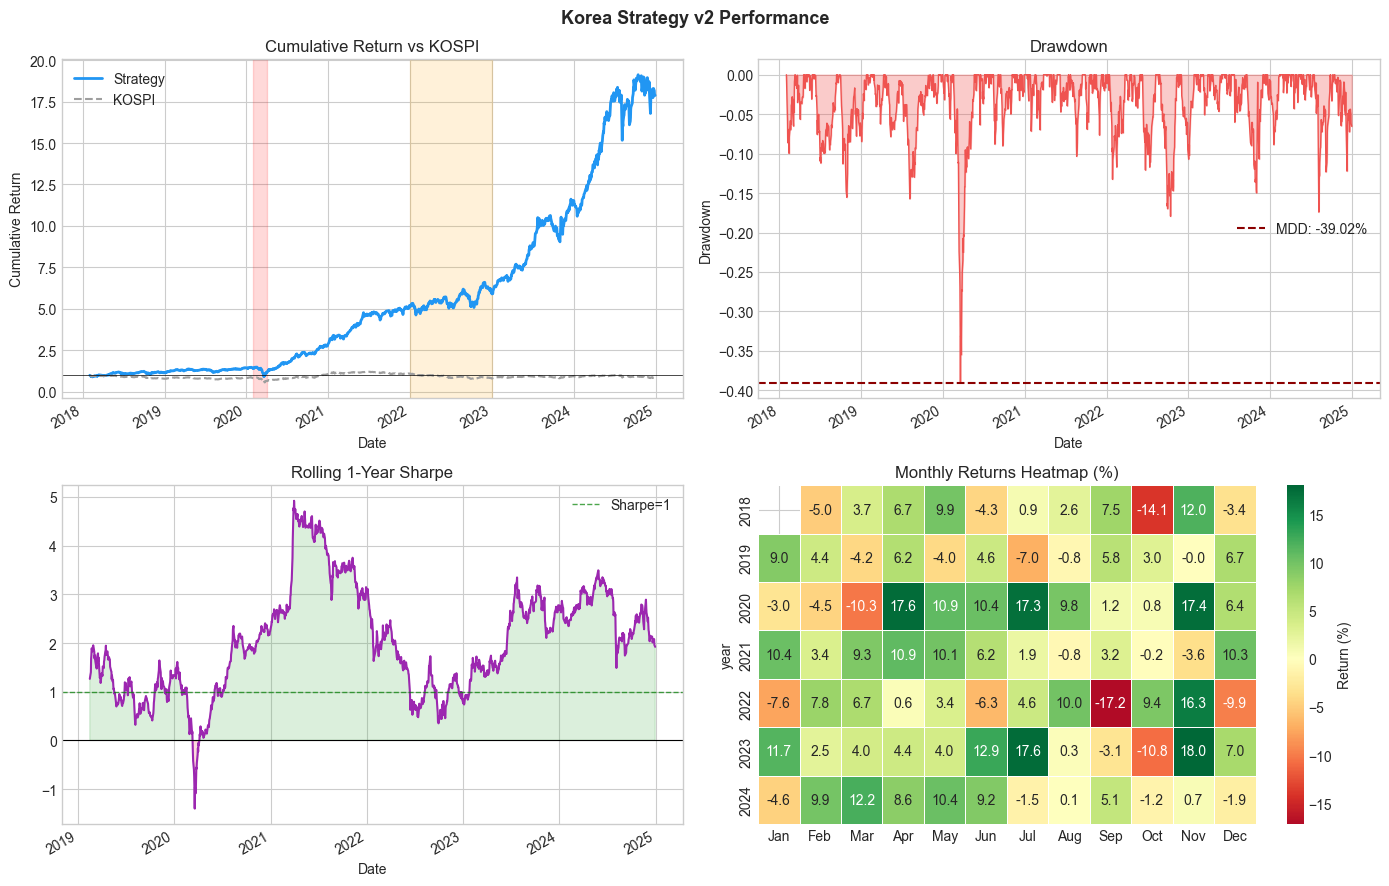

Saved: results/kr_02_performance.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

cum_s  = (1 + net_ret).cumprod()
cum_bm = (1 + bm_ret.dropna()).cumprod()

# 누적 수익률
ax = axes[0, 0]
cum_s.plot(ax=ax, color='#2196F3', lw=2, label='Strategy')
cum_bm.plot(ax=ax, color='#9E9E9E', lw=1.5,
             linestyle='--', label='KOSPI')
ax.axhline(1, color='black', lw=0.5)
# 주요 사건 표시
ax.axvspan('2020-02-01', '2020-04-01',
            alpha=0.15, color='red')
ax.axvspan('2022-01-01', '2022-12-31',
            alpha=0.15, color='orange')
ax.set_title('Cumulative Return vs KOSPI')
ax.set_ylabel('Cumulative Return')
ax.legend()

# 드로우다운
ax = axes[0, 1]
dd = (cum_s - cum_s.cummax()) / cum_s.cummax()
dd.plot(ax=ax, color='#EF5350', lw=1)
ax.fill_between(dd.index, dd, 0,
                color='#EF5350', alpha=0.3)
ax.axhline(s_mdd, color='darkred', lw=1.5,
           linestyle='--', label=f'MDD: {s_mdd:.2%}')
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
ax.legend()

# 롤링 샤프
ax = axes[1, 0]
roll_sh = (
    net_ret.rolling(252).mean() * 252 /
    (net_ret.rolling(252).std() * np.sqrt(252))
)
roll_sh.plot(ax=ax, color='#9C27B0', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1, color='green', lw=1,
           linestyle='--', alpha=0.7, label='Sharpe=1')
ax.fill_between(roll_sh.index, roll_sh, 0,
                where=roll_sh >= 0,
                color='#4CAF50', alpha=0.2)
ax.fill_between(roll_sh.index, roll_sh, 0,
                where=roll_sh < 0,
                color='#EF5350', alpha=0.2)
ax.set_title('Rolling 1-Year Sharpe')
ax.legend()

# 월별 히트맵
ax = axes[1, 1]
monthly = net_ret.resample('M').sum()
mdf = pd.DataFrame({
    'year' : monthly.index.year,
    'month': monthly.index.month,
    'ret'  : monthly.values
})
pivot = mdf.pivot(index='year', columns='month', values='ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(pivot * 100, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'Return (%)'})
ax.set_title('Monthly Returns Heatmap (%)')
ax.set_xlabel('')

plt.suptitle('Korea Strategy v2 Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/kr_02_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/kr_02_performance.png')

---
## Cell 8 — 저장 & KIS API 연결 준비

In [13]:
# 전체 저장
net_ret.to_csv('data/processed/kr_net_returns.csv')
positions.to_csv('data/processed/kr_positions.csv')
clean_df.to_csv('data/processed/kr_feature_df.csv', index=False)

print('=' * 50)
print(' Korea Strategy v2 — Final Report')
print('=' * 50)
print(f'  기간        : {net_ret.index[0].date()} ~ {net_ret.index[-1].date()}')
print(f'  유니버스    : KOSPI 상위 {len(common_tickers)}개 종목')
print(f'  전략        : 팩터 상위 20종목 롱온리')
print(f'  리밸런싱    : 월 1회')
print(f'  거래비용    : 편도 {TRANSACTION_COST:.1%}')
print()
print(f'  연수익률    : {s_ret:.2%}')
print(f'  Sharpe      : {s_sh:.3f}')
print(f'  MDD         : {s_mdd:.2%}')
print()

# 오늘 기준 매수 후보 종목 출력
print('현재 시점 매수 후보 (상위 20종목):')
latest_date = clean_df['date'].max()
latest_df   = clean_df[clean_df['date'] == latest_date]
top20_now   = latest_df.nlargest(20, 'prediction')

print(f'  기준일: {latest_date.date()}')
print(f'  {"순위":>4} | {"티커":>8} | {"종목명":>12} | {"점수":>8}')
print('  ' + '-' * 40)
for rank, (_, row) in enumerate(top20_now.iterrows(), 1):
    name = names.get(row['ticker'], row['ticker'])
    print(f'  {rank:>4} | {row["ticker"]:>8} | '
          f'{name:>12} | {row["prediction"]:>8.5f}')

print('\n' + '=' * 50)
print(' 완료! 다음: KIS API로 자동매매 연결')
print('=' * 50)

 Korea Strategy v2 — Final Report
  기간        : 2018-02-01 ~ 2024-12-30
  유니버스    : KOSPI 상위 81개 종목
  전략        : 팩터 상위 20종목 롱온리
  리밸런싱    : 월 1회
  거래비용    : 편도 0.3%

  연수익률    : 45.78%
  Sharpe      : 1.755
  MDD         : -39.02%

현재 시점 매수 후보 (상위 20종목):
  기준일: 2024-10-31
    순위 |       티커 |          종목명 |       점수
  ----------------------------------------
     1 |   090430 |       아모레퍼시픽 |  0.08828
     2 |   011070 |        LG이노텍 |  0.06419
     3 |   161390 |  한국타이어앤테크놀로지 |  0.06244
     4 |   006260 |           LS |  0.05286
     5 |   005380 |          현대차 |  0.05272
     6 |   267260 |     HD현대일렉트릭 |  0.05098
     7 |   066570 |         LG전자 |  0.04667
     8 |   267270 |       HD건설기계 |  0.04360
     9 |   042700 |        한미반도체 |  0.04078
    10 |   028050 |        삼성E&A |  0.03226
    11 |   028260 |         삼성물산 |  0.03207
    12 |   000810 |         삼성화재 |  0.03030
    13 |   000500 |         가온전선 |  0.02934
    14 |   009830 |        한화솔루션 |  0.02829
    15 |   010140 |    

In [14]:
# 최신 데이터로 신호 업데이트
import yfinance as yf
import datetime

print('최신 데이터로 신호 업데이트 중...')

# 오늘 날짜 기준 추가 데이터 수집
today     = datetime.datetime.today().strftime('%Y-%m-%d')
new_data  = {}

for code in tickers_valid[:]:
    try:
        df = fdr.DataReader(code, '2024-01-01', today)
        if len(df) > 10:
            new_data[code] = df['Close']
        time.sleep(0.05)
    except:
        continue

# 기존 prices에 붙이기
prices_new = pd.DataFrame(new_data)
prices_new.index = pd.to_datetime(prices_new.index)
prices_updated = pd.concat([prices, prices_new]).sort_index()
prices_updated = prices_updated[~prices_updated.index.duplicated(keep='last')]

lr_updated = np.log(
    prices_updated / prices_updated.shift(1)
).clip(-0.5, 0.5)

print(f'업데이트된 기간: {prices_updated.index[-1].date()}까지')

# 팩터 재계산
mom_new   = cross_sectional_zscore(
    (lr_updated.rolling(252).sum() - lr_updated.rolling(21).sum()) /
    (lr_updated.rolling(63).std() * np.sqrt(252))
)
vol_new   = lr_updated.rolling(63).std() * np.sqrt(252)
high_new  = prices_updated.rolling(252).max()
val_new   = cross_sectional_zscore(-(prices_updated / high_new))
pos_new   = lr_updated.rolling(252).apply(lambda x: (x>0).mean(), raw=True)
sh_new    = (lr_updated.rolling(252).mean()*252 /
             (lr_updated.rolling(252).std()*np.sqrt(252)))
qual_new  = cross_sectional_zscore(
    (cross_sectional_zscore(-vol_new) +
     cross_sectional_zscore(pos_new) +
     cross_sectional_zscore(sh_new)) / 3
)
srev_new  = cross_sectional_zscore(-lr_updated.rolling(5).sum())

# IC 부호 수정 적용
if ic_signs.get('모멘텀', 0)   < 0: mom_new  = -mom_new
if ic_signs.get('가치', 0)     < 0: val_new  = -val_new
if ic_signs.get('퀄리티', 0)   < 0: qual_new = -qual_new
if ic_signs.get('단기반전', 0) < 0: srev_new = -srev_new

# 오늘 기준 피처
today_date = lr_updated.index[-1]
records_today = []
for ticker in prices_updated.columns:
    try:
        f_mom  = float(mom_new.loc[today_date, ticker])  if ticker in mom_new.columns  else 0
        f_val  = float(val_new.loc[today_date, ticker])  if ticker in val_new.columns  else 0
        f_qual = float(qual_new.loc[today_date, ticker]) if ticker in qual_new.columns else 0
        f_srev = float(srev_new.loc[today_date, ticker]) if ticker in srev_new.columns else 0
        f_1m   = float(lr_updated.rolling(21).sum().loc[today_date, ticker])
        f_vol  = float(vol_new.loc[today_date, ticker])

        if any(np.isnan([f_mom, f_val, f_qual])):
            continue

        records_today.append({
            'ticker'   : ticker,
            'mom'      : f_mom,
            'value'    : f_val,
            'quality'  : f_qual,
            'short_rev': f_srev if not np.isnan(f_srev) else 0,
            'mom_1m'   : f_1m   if not np.isnan(f_1m)   else 0,
            'vol'      : f_vol  if not np.isnan(f_vol)  else 0.2,
        })
    except:
        continue

today_df = pd.DataFrame(records_today)
today_df['score'] = model.predict(
    today_df[FEATURE_COLS].fillna(0).values
)

top20_today = today_df.nlargest(20, 'score')

print(f'\n최신 매수 후보 (기준일: {today_date.date()})')
print(f'  {"순위":>4} | {"티커":>8} | {"종목명":>15} | {"점수":>8}')
print('  ' + '-' * 45)
for rank, (_, row) in enumerate(top20_today.iterrows(), 1):
    name = names.get(row['ticker'], row['ticker'])
    print(f'  {rank:>4} | {row["ticker"]:>8} | '
          f'{name:>15} | {row["score"]:>8.5f}')

# 저장
top20_today.to_csv('data/processed/kr_latest_signal.csv', index=False)
print('\n최신 신호 저장: data/processed/kr_latest_signal.csv')

최신 데이터로 신호 업데이트 중...
업데이트된 기간: 2026-05-26까지

최신 매수 후보 (기준일: 2026-05-26)
    순위 |       티커 |             종목명 |       점수
  ---------------------------------------------
     1 |   005930 |            삼성전자 |  0.12865
     2 |   009150 |            삼성전기 |  0.12042
     3 |   005935 |           삼성전자우 |  0.08570
     4 |   035720 |             카카오 |  0.07424
     5 |   003490 |            대한항공 |  0.07383
     6 |   000660 |          SK하이닉스 |  0.06790
     7 |   066970 |            엘앤에프 |  0.06303
     8 |   028050 |           삼성E&A |  0.05514
     9 |   034730 |              SK |  0.05430
    10 |   011200 |             HMM |  0.05035
    11 |   006400 |           삼성SDI |  0.04874
    12 |   032830 |            삼성생명 |  0.04594
    13 |   010130 |            고려아연 |  0.04592
    14 |   161390 |     한국타이어앤테크놀로지 |  0.04535
    15 |   000880 |              한화 |  0.04350
    16 |   005387 |          현대차2우B |  0.04214
    17 |   267250 |            HD현대 |  0.04209
    18 |   034020 |         두산에너빌리